<a href="https://sigmoidal.ai/en/">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="400">
</a>

# Detecting Image Blur with the Fast Fourier Transform

**Author:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai/en/)

This notebook implements a global sharpness baseline based on the two-dimensional Fast Fourier Transform (FFT), validates it under progressively stronger Gaussian blur, and compares its response with the variance of the Laplacian.

---

In [1]:
import hashlib
import urllib.request

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "image.cmap": "gray",
})

## Why blur suppresses high spatial frequencies

Blur can be represented as the convolution of an original image $f(x, y)$ with a point-spread function $h(x, y)$:

$$g(x, y) = f(x, y) * h(x, y)$$

In the frequency domain, convolution becomes multiplication:

$$G(u, v) = F(u, v) \cdot H(u, v)$$

For Gaussian blur, $H(u, v)$ behaves as a **low-pass filter**: it preserves low spatial frequencies while attenuating the high-frequency components associated with edges and fine texture. A sharp image therefore tends to retain more energy away from the center of its Fourier spectrum than a blurred version of the same scene.

## The two-dimensional Fourier transform

For an $M \times N$ grayscale image $f(x, y)$, the two-dimensional discrete Fourier transform is

$$F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x, y)\, e^{-j\,2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}.$$

NumPy computes this transform with `np.fft.fft2`. The call to `np.fft.fftshift` moves the zero-frequency, or DC, component to the center of the displayed spectrum. A logarithmic magnitude makes both weak and strong components visible:

$$\operatorname{magnitude}(u, v) = \log_{10}\!\left(1 + |F(u, v)|\right).$$

## Loading and validating the reference images

Both photographs are stored in the public Sigmoidal notebook repository. Their SHA-256 hashes are checked before decoding so that the experiment cannot silently change if a remote file is replaced.

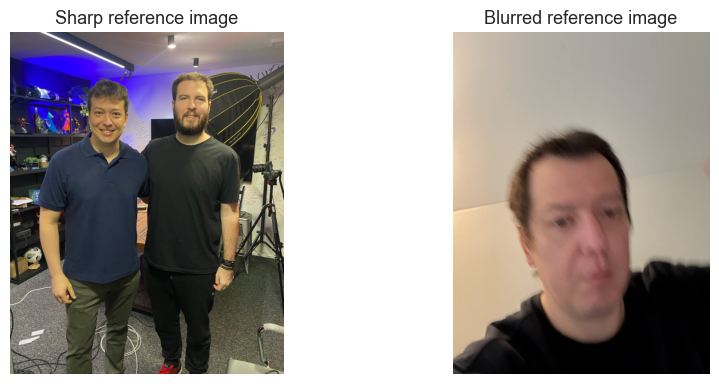

In [2]:
SHARP_IMAGE_URL = (
    "https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/"
    "Deteccao-de-Blur-com-FFT/imagem_nitida.jpg"
)
BLURRED_IMAGE_URL = (
    "https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/"
    "Deteccao-de-Blur-com-FFT/imagem_borrada.jpg"
)
EXPECTED_SHA256 = {
    SHARP_IMAGE_URL: "a7d010c492518f36298c744e19001826f97f2415438349dedde08d19f7c078f4",
    BLURRED_IMAGE_URL: "a5e098a1517bd4bba8520ee5fb7d0d7c00c18210607d09ce47bf3ee12ac91e5a",
}


def url_to_image(url):
    """Download, verify, and decode an image as a BGR array."""
    payload = urllib.request.urlopen(url).read()
    digest = hashlib.sha256(payload).hexdigest()
    if digest != EXPECTED_SHA256[url]:
        raise ValueError(f"Unexpected SHA-256 for {url}: {digest}")
    data = np.frombuffer(payload, dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"OpenCV could not decode {url}")
    return image


def resize_width(image, width=500):
    """Resize an image to a fixed width while preserving its aspect ratio."""
    height, original_width = image.shape[:2]
    scale = width / float(original_width)
    return cv2.resize(
        image,
        (width, int(height * scale)),
        interpolation=cv2.INTER_AREA,
    )


sharp_image = resize_width(url_to_image(SHARP_IMAGE_URL), width=500)
blurred_image = resize_width(url_to_image(BLURRED_IMAGE_URL), width=500)

sharp_gray = cv2.cvtColor(sharp_image, cv2.COLOR_BGR2GRAY)
blurred_gray = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(sharp_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Sharp reference image")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB))
axes[1].set_title("Blurred reference image")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Comparing the magnitude spectra

The two images depict the same subject under different focus conditions. This controlled comparison makes the shift in spectral energy easier to interpret: the blurred image should show less energy away from the low-frequency center.

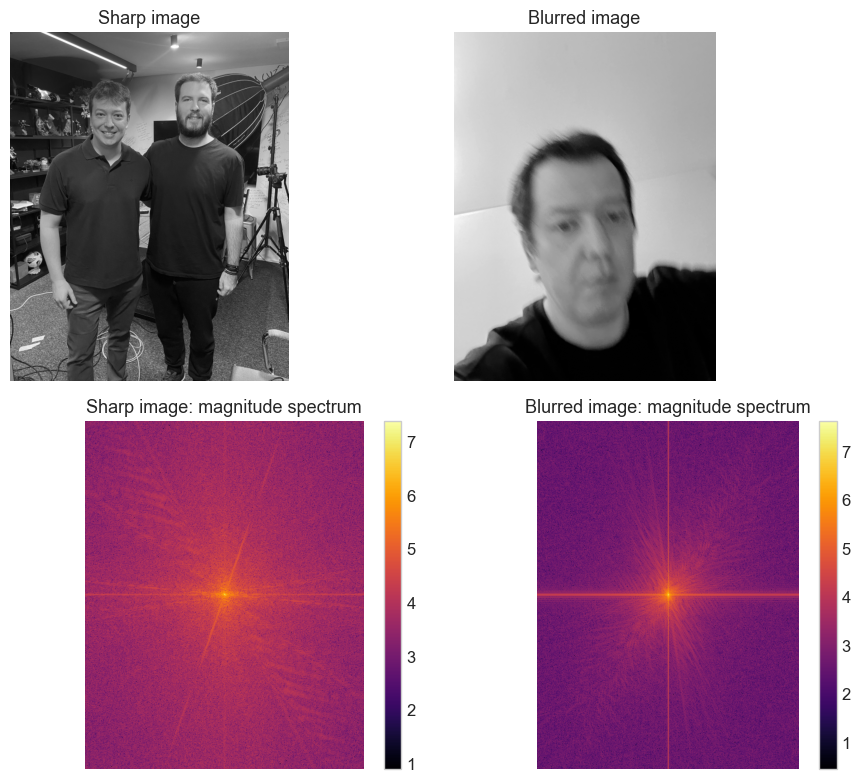

In [3]:
def magnitude_spectrum(image):
    """Return the centered logarithmic magnitude spectrum of an image."""
    shifted = np.fft.fftshift(np.fft.fft2(image))
    return np.log10(1 + np.abs(shifted))


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for column, (image, title) in enumerate([
    (sharp_gray, "Sharp image"),
    (blurred_gray, "Blurred image"),
]):
    axes[0, column].imshow(image, cmap="gray")
    axes[0, column].set_title(title)
    axes[0, column].axis("off")

    spectrum = magnitude_spectrum(image)
    rendered = axes[1, column].imshow(spectrum, cmap="inferno")
    axes[1, column].set_title(f"{title}: magnitude spectrum")
    axes[1, column].axis("off")
    plt.colorbar(rendered, ax=axes[1, column], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Implementing a global FFT blur score

The baseline follows five operations:

1. Compute and center the two-dimensional FFT.
2. Remove a circular region of radius `size` around the low-frequency center.
3. Apply the inverse FFT to reconstruct the retained high-frequency content.
4. Average the magnitude of that reconstruction.
5. Compare the score with a calibrated threshold.

This didactic global score is **inspired by spectral blur analysis**, but it is not a reproduction of the patch classifier described by [Liu, Li, and Jia (CVPR 2008)](https://doi.org/10.1109/CVPR.2008.4587465).

In [4]:
def detect_blur_fft(image, size=60, threshold=5):
    """Measure retained high-frequency magnitude in a grayscale image.

    Parameters
    ----------
    image : numpy.ndarray
        Two-dimensional grayscale image.
    size : int
        Radius of the circular low-frequency region to remove.
    threshold : float
        Application-specific cutoff below which the image is labeled blurred.

    Returns
    -------
    mean_magnitude : float
        Mean magnitude of the reconstructed high-frequency signal.
    is_blurry : bool
        True when `mean_magnitude` is less than or equal to `threshold`.
    """
    if image.ndim != 2:
        raise ValueError("The input must be a two-dimensional grayscale image.")
    if size <= 0:
        raise ValueError("size must be positive.")

    height, width = image.shape
    center_y, center_x = height // 2, width // 2

    shifted = np.fft.fftshift(np.fft.fft2(image))

    y_coordinates, x_coordinates = np.ogrid[:height, :width]
    radius = np.sqrt(
        (x_coordinates - center_x) ** 2 + (y_coordinates - center_y) ** 2
    )
    shifted[radius <= size] = 0

    reconstructed = np.fft.ifft2(np.fft.ifftshift(shifted))
    mean_magnitude = float(np.mean(np.abs(reconstructed)))
    is_blurry = mean_magnitude <= threshold
    return mean_magnitude, is_blurry

## Applying the detector

The mask radius and threshold below are calibrated only for the resized reference images in this notebook. They should not be treated as universal constants.

In [5]:
MASK_RADIUS = 60
THRESHOLD = 5

sharp_score, sharp_is_blurry = detect_blur_fft(
    sharp_gray, size=MASK_RADIUS, threshold=THRESHOLD
)
blurred_score, blurred_is_blurry = detect_blur_fft(
    blurred_gray, size=MASK_RADIUS, threshold=THRESHOLD
)

assert sharp_score > THRESHOLD and not sharp_is_blurry
assert blurred_score <= THRESHOLD and blurred_is_blurry

print(
    f"Sharp image   — FFT score: {sharp_score:.2f} | "
    f"{'BLURRED' if sharp_is_blurry else 'SHARP'}"
)
print(
    f"Blurred image — FFT score: {blurred_score:.2f} | "
    f"{'BLURRED' if blurred_is_blurry else 'SHARP'}"
)

Sharp image   — FFT score: 9.03 | SHARP
Blurred image — FFT score: 2.30 | BLURRED


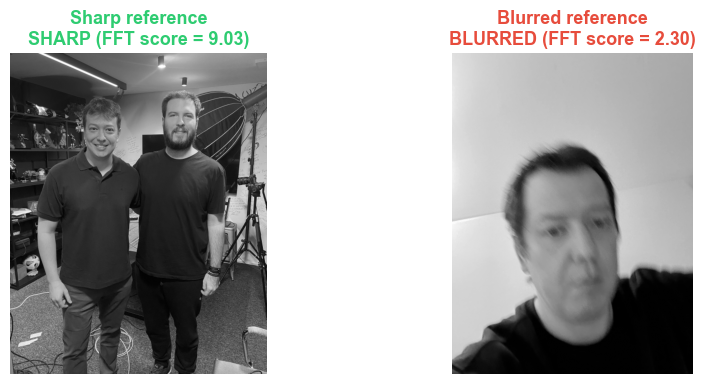

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for axis, image, score, is_blurry, title in [
    (axes[0], sharp_gray, sharp_score, sharp_is_blurry, "Sharp reference"),
    (axes[1], blurred_gray, blurred_score, blurred_is_blurry, "Blurred reference"),
]:
    axis.imshow(image, cmap="gray")
    label = "BLURRED" if is_blurry else "SHARP"
    color = "#e74c3c" if is_blurry else "#2ecc71"
    axis.set_title(
        f"{title}\n{label} (FFT score = {score:.2f})",
        color=color,
        fontweight="bold",
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

## Stress-testing the score with progressive Gaussian blur

To test whether the score responds consistently, the sharp reference is filtered with odd Gaussian kernels from 1 to 31 pixels. The experiment changes one variable while holding the scene, image size, mask radius, and decision threshold constant.

In [7]:
kernel_sizes = list(range(1, 32, 2))
fft_scores = []

for kernel_size in kernel_sizes:
    progressively_blurred = (
        cv2.GaussianBlur(sharp_gray, (kernel_size, kernel_size), 0)
        if kernel_size > 1
        else sharp_gray.copy()
    )
    score, is_blurry = detect_blur_fft(
        progressively_blurred,
        size=MASK_RADIUS,
        threshold=THRESHOLD,
    )
    fft_scores.append(score)
    status = "BLURRED" if is_blurry else "SHARP"
    print(f"Kernel {kernel_size:2d} — FFT score: {score:8.2f} — {status}")

assert all(
    later <= earlier
    for earlier, later in zip(fft_scores, fft_scores[1:])
), "The FFT score did not decrease monotonically in this controlled experiment."

Kernel  1 — FFT score:     9.03 — SHARP
Kernel  3 — FFT score:     6.00 — SHARP
Kernel  5 — FFT score:     4.81 — BLURRED
Kernel  7 — FFT score:     3.54 — BLURRED
Kernel  9 — FFT score:     2.78 — BLURRED
Kernel 11 — FFT score:     2.18 — BLURRED
Kernel 13 — FFT score:     1.69 — BLURRED


Kernel 15 — FFT score:     1.39 — BLURRED
Kernel 17 — FFT score:     1.19 — BLURRED
Kernel 19 — FFT score:     1.05 — BLURRED
Kernel 21 — FFT score:     0.99 — BLURRED
Kernel 23 — FFT score:     0.94 — BLURRED
Kernel 25 — FFT score:     0.92 — BLURRED
Kernel 27 — FFT score:     0.91 — BLURRED


Kernel 29 — FFT score:     0.90 — BLURRED
Kernel 31 — FFT score:     0.89 — BLURRED


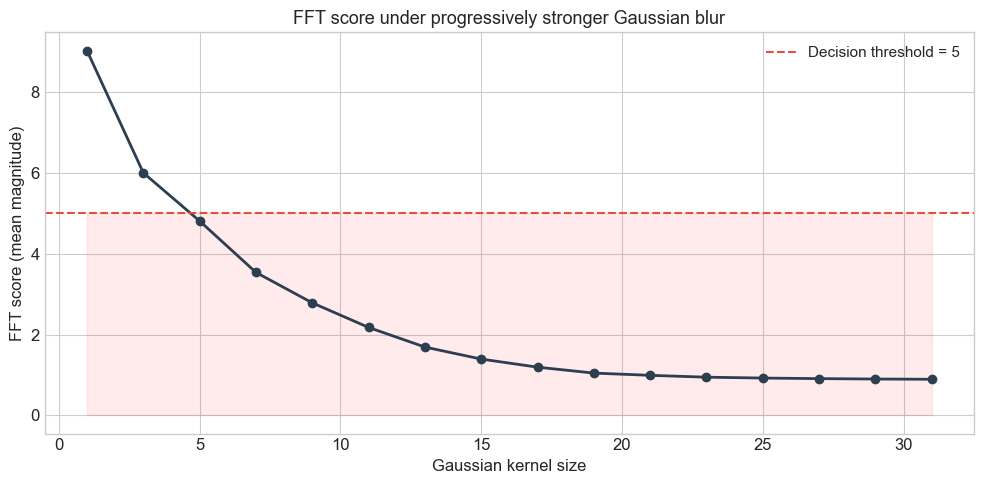

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(
    kernel_sizes,
    fft_scores,
    "o-",
    color="#2c3e50",
    linewidth=2,
    markersize=6,
)
plt.axhline(
    y=THRESHOLD,
    color="#e74c3c",
    linestyle="--",
    linewidth=1.5,
    label=f"Decision threshold = {THRESHOLD}",
)
plt.fill_between(kernel_sizes, 0, THRESHOLD, alpha=0.08, color="red")
plt.xlabel("Gaussian kernel size")
plt.ylabel("FFT score (mean magnitude)")
plt.title("FFT score under progressively stronger Gaussian blur")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Comparing FFT with the variance of the Laplacian

The variance of the Laplacian is a compact spatial-domain focus measure. A sharp image produces strong second-order responses around edges and therefore a higher variance; smoothing attenuates those responses. The comparison below normalizes both sequences to their own first value, so it compares response shape rather than absolute units.

Pech-Pacheco and colleagues evaluated Laplacian-based focus measures for microscopy in [ICPR 2000](https://doi.org/10.1109/ICPR.2000.903548).

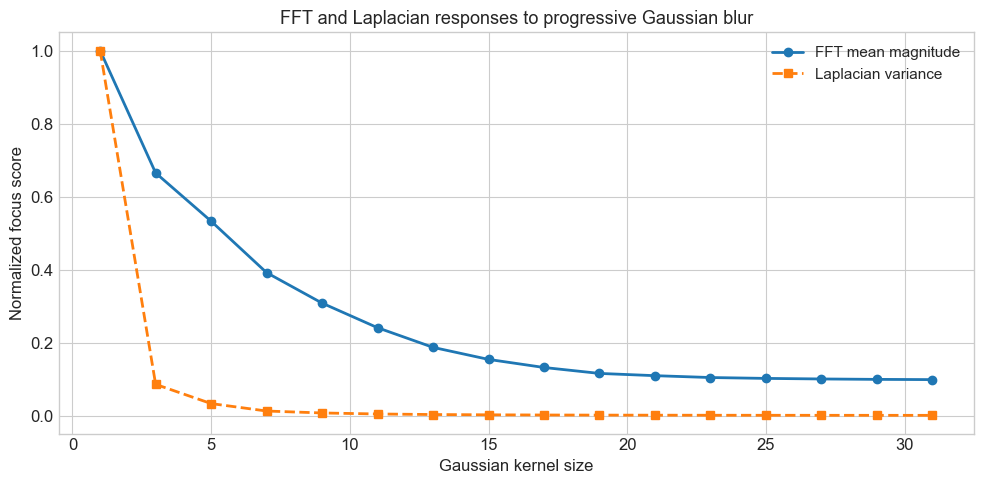

FFT normalized score at kernel 5: 0.533
Laplacian normalized score at kernel 5: 0.033


In [9]:
def laplacian_variance(image):
    """Return the variance of the image Laplacian as a focus measure."""
    return float(cv2.Laplacian(image, cv2.CV_64F).var())


laplacian_scores = []
for kernel_size in kernel_sizes:
    progressively_blurred = (
        cv2.GaussianBlur(sharp_gray, (kernel_size, kernel_size), 0)
        if kernel_size > 1
        else sharp_gray.copy()
    )
    laplacian_scores.append(laplacian_variance(progressively_blurred))

fft_normalized = np.asarray(fft_scores) / fft_scores[0]
laplacian_normalized = np.asarray(laplacian_scores) / laplacian_scores[0]

plt.figure(figsize=(10, 5))
plt.plot(
    kernel_sizes,
    fft_normalized,
    "o-",
    label="FFT mean magnitude",
    linewidth=2,
    markersize=6,
)
plt.plot(
    kernel_sizes,
    laplacian_normalized,
    "s--",
    label="Laplacian variance",
    linewidth=2,
    markersize=6,
)
plt.xlabel("Gaussian kernel size")
plt.ylabel("Normalized focus score")
plt.title("FFT and Laplacian responses to progressive Gaussian blur")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"FFT normalized score at kernel 5: {fft_normalized[2]:.3f}")
print(f"Laplacian normalized score at kernel 5: {laplacian_normalized[2]:.3f}")

## How does the spectrum change as blur increases?

The last panel keeps the source image fixed and changes only the Gaussian kernel. As smoothing grows, the visible spectrum contracts toward the low-frequency center.

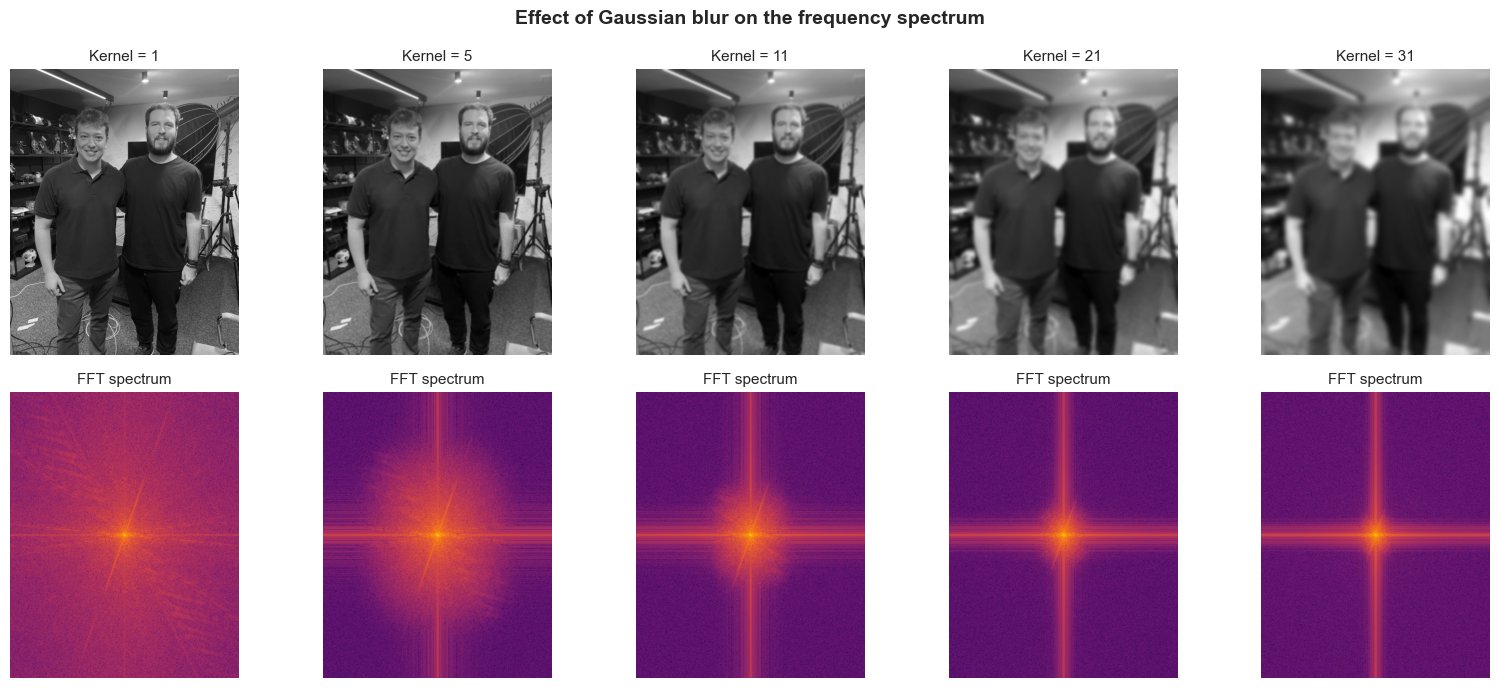

In [10]:
selected_kernel_sizes = [1, 5, 11, 21, 31]
fig, axes = plt.subplots(2, len(selected_kernel_sizes), figsize=(16, 7))

for index, kernel_size in enumerate(selected_kernel_sizes):
    progressively_blurred = (
        cv2.GaussianBlur(sharp_gray, (kernel_size, kernel_size), 0)
        if kernel_size > 1
        else sharp_gray.copy()
    )

    axes[0, index].imshow(progressively_blurred, cmap="gray")
    axes[0, index].set_title(f"Kernel = {kernel_size}", fontsize=11)
    axes[0, index].axis("off")

    axes[1, index].imshow(magnitude_spectrum(progressively_blurred), cmap="inferno")
    axes[1, index].set_title("FFT spectrum", fontsize=11)
    axes[1, index].axis("off")

axes[0, 0].set_ylabel("Image", fontsize=12)
axes[1, 0].set_ylabel("Frequency domain", fontsize=12)
plt.suptitle(
    "Effect of Gaussian blur on the frequency spectrum",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Limitations of a global frequency score

This experiment establishes a controlled response to Gaussian blur, not universal blur detection. Important failure modes include:

- **Low-texture scenes:** a clear sky or blank wall can contain little high-frequency energy even when correctly focused.
- **Partial blur:** one global score can hide a blurred region surrounded by sharp content.
- **Motion blur:** directional attenuation differs from the isotropic Gaussian blur tested here.
- **JPEG artifacts and sensor noise:** both can add high-frequency energy and inflate the score.
- **Resolution and content dependence:** `size` and `threshold` must be calibrated for the acquisition system and expected scenes.

Production systems should evaluate patch-level analysis, complementary focus measures, or learned models on a labeled validation set representative of the deployment domain.

## Takeaways

- Gaussian blur behaves as a **low-pass filter**, suppressing edges and fine detail.
- A two-dimensional FFT exposes this loss of high-frequency content directly.
- The global baseline removes the low-frequency center and measures the retained signal.
- In this controlled sequence, the FFT score decreases monotonically as Gaussian blur increases.
- Laplacian variance reacts more sharply to the first levels of smoothing, while the FFT score decays more gradually.
- Neither score provides a universal threshold; deployment requires calibration and failure-case testing.